In [ ]:
# ===============================
# 📦 Cell 1: Install Dependencies
# ===============================
!pip install transformers accelerate torch torchvision scikit-learn matplotlib seaborn --quiet

In [ ]:
# ===============================
# 🔄 Cell 2: Setup & Model Loading (CLIP)
# ===============================
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import os
from google.colab import drive
import pandas as pd
from datetime import datetime
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Paths
base_path = '/content/drive/MyDrive/TRB2026_sharmin/css-data'
subfolders = ['test', 'valid']

Mounted at /content/drive


In [ ]:
# Load CLIP
model_version = "openai/clip-vit-base-patch16"
clip_model = CLIPModel.from_pretrained(model_version)
clip_processor = CLIPProcessor.from_pretrained(model_version)
clip_model.to("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [ ]:
result_folder_name = "result_clip_exp4"

In [ ]:
# Prompts
label_prompts = {
    0: "A man or woman at a construction site wearing a hardhat",
    7: "A construction worker in a fluorescent safety vest",
    6: "A cone marking a hazard on the road",
    8: "Excavation or lifting machinery used at construction sites",
    9: "A truck or vehicle moving through a construction zone"
}
label_names = {
    0: "Helmet",
    7: "Safety Vest",
    6: "Safety Cone",
    8: "Machinery",
    9: "Vehicle"
}

In [ ]:
# Inference
threshold = 0.3

def classify_clip(image_path, label_prompts):
    image = Image.open(image_path).convert("RGB")
    texts = list(label_prompts.values())
    inputs = clip_processor(text=texts, images=image, return_tensors="pt", padding=True).to(clip_model.device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1).squeeze().cpu().numpy()
    predicted = [i for i, p in enumerate(probs) if p > threshold]
    return [list(label_prompts.keys())[i] for i in predicted]

In [ ]:
# ===============================
# 🧠 Cell 3: Run CLIP Inference & Save Labels
# ===============================
for sub in subfolders:
    image_folder = os.path.join(base_path, sub, "images")
    output_label_folder = os.path.join(base_path, sub, result_folder_name)
    os.makedirs(output_label_folder, exist_ok=True)

    for img_file in os.listdir(image_folder):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(image_folder, img_file)
        predicted_labels = classify_clip(img_path, label_prompts)
        label_filename = os.path.splitext(img_file)[0] + ".txt"
        output_path = os.path.join(output_label_folder, label_filename)
        with open(output_path, 'w') as f:
            for label in sorted(predicted_labels):
                f.write(f"{label}\n")

print("✅ CLIP predictions saved to", result_folder_name)

✅ CLIP predictions saved to result_clip_exp4


In [ ]:
# Create export directory with timestamp
now = datetime.now().strftime("%Y%m%d_%H%M%S")
export_dir = os.path.join(base_path, f"{result_folder_name}_" + now)
os.makedirs(export_dir, exist_ok=True)

In [ ]:
# ===============================
# 📊 Cell 4: Evaluation
# ===============================
true_labels, pred_labels = [], []
for sub in subfolders:
    image_dir = os.path.join(base_path, sub, "images")
    gt_dir = os.path.join(base_path, sub, "labels_superclean_GT")
    pred_dir = os.path.join(base_path, sub, result_folder_name)

    for file in os.listdir(image_dir):
        if not file.endswith(('.jpg', '.jpeg', '.png')):
            continue
        name = os.path.splitext(file)[0]
        gt_path = os.path.join(gt_dir, name + ".txt")
        pr_path = os.path.join(pred_dir, name + ".txt")
        if not os.path.exists(gt_path) or not os.path.exists(pr_path):
            continue
        with open(gt_path) as f:
            gt = [int(x.strip()) for x in f if x.strip().isdigit()]
        with open(pr_path) as f:
            pr = [int(x.strip()) for x in f if x.strip().isdigit()]
        true_labels.append(gt)
        pred_labels.append(pr)

In [ ]:
from sklearn.metrics import classification_report
mlb = MultiLabelBinarizer(classes=sorted(label_prompts.keys()))
y_true = mlb.fit_transform(true_labels)
y_pred = mlb.transform(pred_labels)

# Metrics
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

# Classification report
report = classification_report(
    y_true, y_pred,
    target_names=[label_names[l] for l in mlb.classes_],
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).T.round(3)
report_df_path = os.path.join(export_dir, "classification_report.csv")
report_df.to_csv(report_df_path)

# Print evaluation summary
print("\n✅ Evaluation Summary")
print("="*50)
print(report_df)
print(f"\nMicro F1: {micro_f1:.3f}, Precision: {micro_precision:.3f}, Recall: {micro_recall:.3f}")
print(f"Macro F1: {macro_f1:.3f}, Precision: {macro_precision:.3f}, Recall: {macro_recall:.3f}")

# Save summary CSV
summary_df = pd.DataFrame({
    'Metric': ['Micro Precision', 'Micro Recall', 'Micro F1', 'Macro Precision', 'Macro Recall', 'Macro F1'],
    'Score': [micro_precision, micro_recall, micro_f1, macro_precision, macro_recall, macro_f1]
}).round(3)
summary_df.to_csv(os.path.join(export_dir, "summary_metrics.csv"), index=False)
print(summary_df)


✅ Evaluation Summary
              precision  recall  f1-score  support
Helmet            0.486   0.250     0.330     72.0
Safety Cone       0.684   0.619     0.650     21.0
Safety Vest       0.453   0.680     0.544     50.0
Machinery         0.506   0.833     0.630     48.0
Vehicle           0.472   0.548     0.507     31.0
micro avg         0.496   0.550     0.521    222.0
macro avg         0.521   0.586     0.532    222.0
weighted avg      0.500   0.550     0.498    222.0
samples avg       0.495   0.419     0.426    222.0

Micro F1: 0.521, Precision: 0.496, Recall: 0.550
Macro F1: 0.532, Precision: 0.521, Recall: 0.586
            Metric  Score
0  Micro Precision  0.496
1     Micro Recall  0.550
2         Micro F1  0.521
3  Macro Precision  0.521
4     Macro Recall  0.586
5         Macro F1  0.532


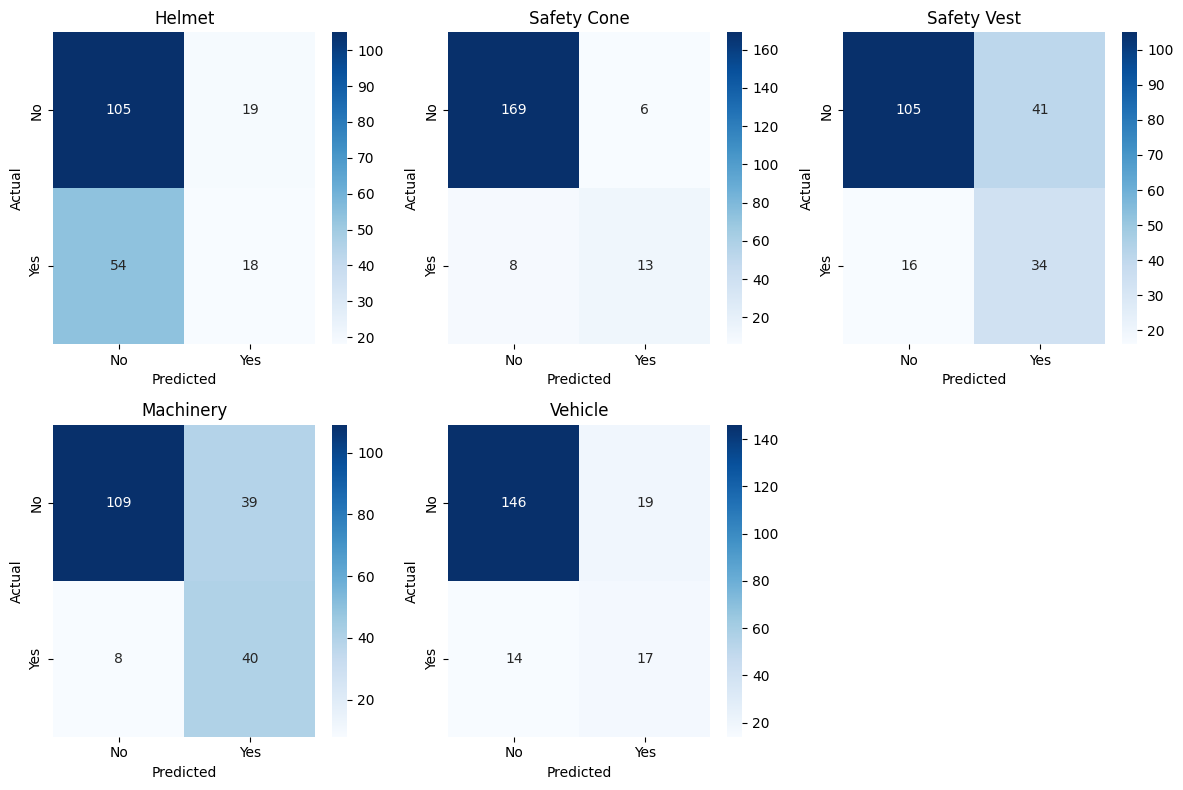

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, label_id in enumerate(mlb.classes_):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(label_names[label_id])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    fig_ind, ax_ind = plt.subplots()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_ind,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax_ind.set_title(label_names[label_id])
    fig_ind.savefig(os.path.join(export_dir, f"conf_matrix_label_{label_id}.png"))
    plt.close(fig_ind)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(os.path.join(export_dir, "confusion_matrices_grid.png"))
plt.show()

In [ ]:
print(f"\n📁 Results saved to: {export_dir}")
print("🎉 Evaluation complete!")


📁 Results saved to: /content/drive/MyDrive/TRB2026_sharmin/css-data/result_clip_exp4_20250910_211911
🎉 Evaluation complete!


In [ ]:
# ===============================
# 📝 Cell 5: Log Run Info to Summary Index
# ===============================
import csv
import json
# Summary log file path
summary_log_path = os.path.join(base_path, "experiment_log.csv")

# Define run metadata
experiment_tag = result_folder_name
label_prompts_str = json.dumps(label_prompts, indent=2)  # pretty-print as JSON"Is there{} in the picture?"  # example prompt used
notes = "Standard prompts with safety gear detection"
summary_row = {
    "timestamp": now,
    "experiment": experiment_tag,
    "macro_precision": round(macro_precision, 3),
    "macro_recall": round(macro_recall, 3),
    "macro_f1": round(macro_f1, 3),
    "micro_precision": round(micro_precision, 3),
    "micro_recall": round(micro_recall, 3),
    "micro_f1": round(micro_f1, 3),
    "result_folder": export_dir,
    "model_version": model_version,
    "notes": notes,
    "prompt": label_prompts_str
}

# Write to CSV (append or create)
write_header = not os.path.exists(summary_log_path)
with open(summary_log_path, mode='a', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=list(summary_row.keys()))
    if write_header:
        writer.writeheader()
    writer.writerow(summary_row)

print(f"✅ Experiment log saved to {summary_log_path}")

✅ Experiment log saved to /content/drive/MyDrive/TRB2026_sharmin/css-data/experiment_log.csv
